# MassSpecGym Precursor Logits Landscape
Load the trained model from `experiments/test_7`, compute precursor logits on the MassSpecGym test set, and plot logits with the target bin highlighted.


In [1]:
import sys
from pathlib import Path

import importlib.util
import numpy as np
import matplotlib.pyplot as plt
import torch

ROOT = Path("..").resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import input_pipeline as ip
from models.bert_torch import BERTTorch

2026-02-05 10:16:36.592096: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-05 10:16:36.624056: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-05 10:16:37.457526: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
/home/wuhao/spectra-learning/.venv/lib/python3.12/site-packages/tqdm

In [2]:
CFG_PATH = ROOT / "configs" / "gems_a_test.py"
spec = importlib.util.spec_from_file_location("cfg", CFG_PATH)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
cfg = mod.get_config()
cfg.tfrecord_dir = str(ROOT / cfg.tfrecord_dir)

dm = ip.TfLightningDataModule(cfg, seed=int(cfg.seed))
info = dm.info
cfg.vocab_size = info["vocab_size"]
cfg.max_length = info["pair_sequence_length"]
cfg.precursor_bins = info["precursor_bins"]
cfg.precursor_offset = info["precursor_offset"]

print("vocab_size:", cfg.vocab_size)
print("precursor_bins:", cfg.precursor_bins, "offset:", cfg.precursor_offset)

vocab_size: 1037
precursor_bins: 1001 offset: 4


In [3]:
workdir = ROOT / "experiments" / "test_12"
ckpt_path = workdir / "checkpoints" / "last.ckpt"
ckpt = torch.load(ckpt_path, map_location="cpu")
state = {
    k[len("model.") :]: v
    for k, v in ckpt["state_dict"].items()
    if k.startswith("model.")
}

model = BERTTorch(
    vocab_size=int(cfg.vocab_size),
    max_length=int(cfg.max_length),
    precursor_bins=int(cfg.precursor_bins),
    precursor_offset=int(cfg.precursor_offset),
    model_dim=int(cfg.model_dim),
    num_layers=int(cfg.num_layers),
    num_heads=int(cfg.num_heads),
    num_kv_heads=cfg.get("num_kv_heads", None),
    attention_mlp_multiple=float(cfg.attention_mlp_multiple),
    num_segments=int(cfg.num_segments),
    mask_ratio=float(cfg.mask_ratio),
    mask_token_id=int(cfg.mask_token_id),
    pad_token_id=int(cfg.pad_token_id),
    cls_token_id=int(cfg.cls_token_id),
    sep_token_id=int(cfg.sep_token_id),
)
model.load_state_dict(state)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

print("loaded checkpoint:", ckpt_path)
print("device:", device)

loaded checkpoint: /home/wuhao/spectra-learning/experiments/test_12/checkpoints/last.ckpt
device: cuda


In [4]:
def collect_precursor_logits(ds, max_examples: int):
    logits_list = []
    labels_list = []
    total = 0

    for batch in ds.as_numpy_iterator():
        batch_torch = ip.numpy_batch_to_torch(batch)
        batch_torch = {
            k: (v.to(device) if isinstance(v, torch.Tensor) else v)
            for k, v in batch_torch.items()
        }

        with torch.no_grad():
            cls_state = model.encode(batch_torch, train=False)
            logits_full = model.precursor_head(cls_state)
            logits = logits_full[:, : cfg.precursor_bins]

        labels = (
            batch_torch["precursor_mz"].to("cpu").numpy() - cfg.precursor_offset
        ).astype(int)

        remaining = max_examples - total
        if remaining <= 0:
            break
        take = min(int(logits.shape[0]), remaining)
        logits_list.append(logits[:take].detach().cpu().numpy())
        labels_list.append(labels[:take])
        total += take

        if total >= max_examples:
            break

    logits_all = np.concatenate(logits_list, axis=0)
    labels_all = np.concatenate(labels_list, axis=0)
    return logits_all, labels_all

In [5]:
max_examples = 8

ds = dm._build_massspec_test_dataset(seed=int(cfg.seed))
logits_all, labels_all = collect_precursor_logits(ds, max_examples=max_examples)

print("massspec logits_all shape:", logits_all.shape)

2026-02-05 10:16:42.024585: I tensorflow/core/kernels/data/tf_record_dataset_op.cc:387] The default buffer size is 262144, which is overridden by the user specified `buffer_size` of 250000


massspec logits_all shape: (8, 1001)


In [11]:
for batch in ds.as_numpy_iterator():
    batch_torch = ip.numpy_batch_to_torch(batch)
    batch_torch = {
        k: (v.to(device) if isinstance(v, torch.Tensor) else v)
        for k, v in batch_torch.items()
    }
    break

In [13]:
batch_torch.keys()

dict_keys(['rt', 'precursor_mz', 'token_ids', 'segment_ids', 'masked_token_ids', 'mlm_mask'])

In [19]:
batch_torch["precursor_mz"][0]

tensor(810, device='cuda:0')

In [21]:
batch_torch["masked_token_ids"][0]

tensor([   1,  138, 1036,  270, 1024,  388, 1017,  206,    3,  288,    3,    3,
        1011,  220,    3,   87, 1010,  248, 1008,    3, 1006,    3, 1006,    3,
        1006,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0], device='cuda:0')

In [18]:
batch_torch["token_ids"][0]

tensor([   1,  138, 1036,  270, 1024,  388, 1017,  206, 1014,  288, 1013,  160,
        1011,  220, 1011,   87, 1010,  248, 1008,  127, 1006,  306, 1006,  145,
        1006,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0], device='cuda:0')

In [20]:
batch_torch["token_ids"][1]

tensor([   1,  649, 1011,  388, 1010,  549, 1006,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,    0,
           0,    0,    0,    0,    0,    0,    0,    0], device='cuda:0')

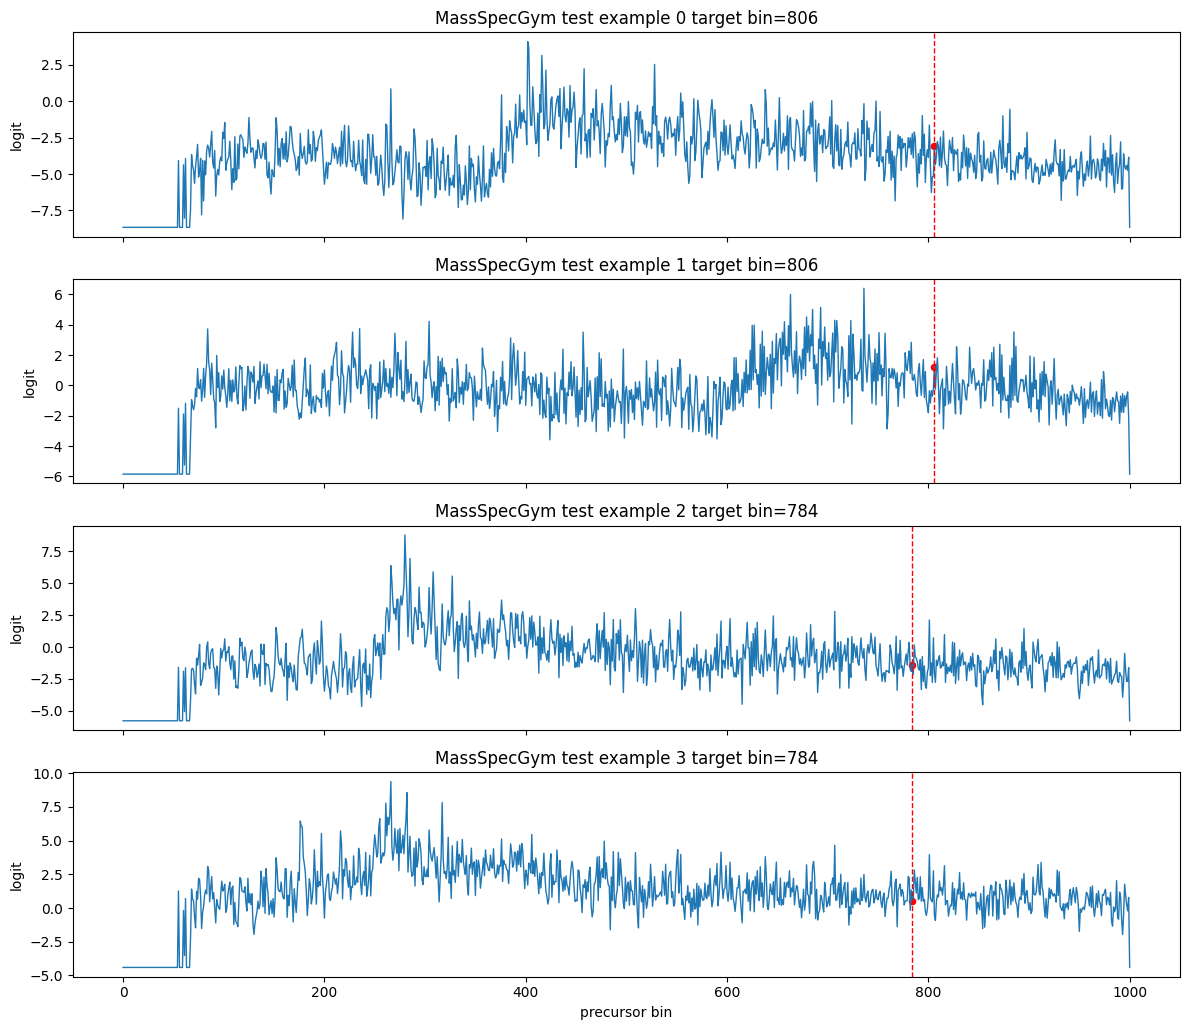

In [6]:
num_examples = min(4, logits_all.shape[0])
fig, axes = plt.subplots(num_examples, 1, figsize=(12, 2.6 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]
for i in range(num_examples):
    ax = axes[i]
    logits_i = logits_all[i]
    target = int(labels_all[i])
    ax.plot(logits_i, color="tab:blue", linewidth=1)
    ax.axvline(target, color="red", linestyle="--", linewidth=1)
    ax.scatter([target], [logits_i[target]], color="red", s=20)
    ax.set_title(f"MassSpecGym test example {i} target bin={target}")
    ax.set_ylabel("logit")
axes[-1].set_xlabel("precursor bin")
plt.tight_layout()
plt.show()

## GeMS Val Precursor Logits (Subset)
Compute logits for a small subset of GeMS val examples and plot with target bins highlighted.


In [7]:
ds_gems = dm._build_gems_val_dataset(seed=int(cfg.seed))
logits_gems, labels_gems = collect_precursor_logits(ds_gems, max_examples=max_examples)

print("gems logits shape:", logits_gems.shape)

gems logits shape: (8, 1001)


TypeError: '_PrefetchDataset' object is not subscriptable

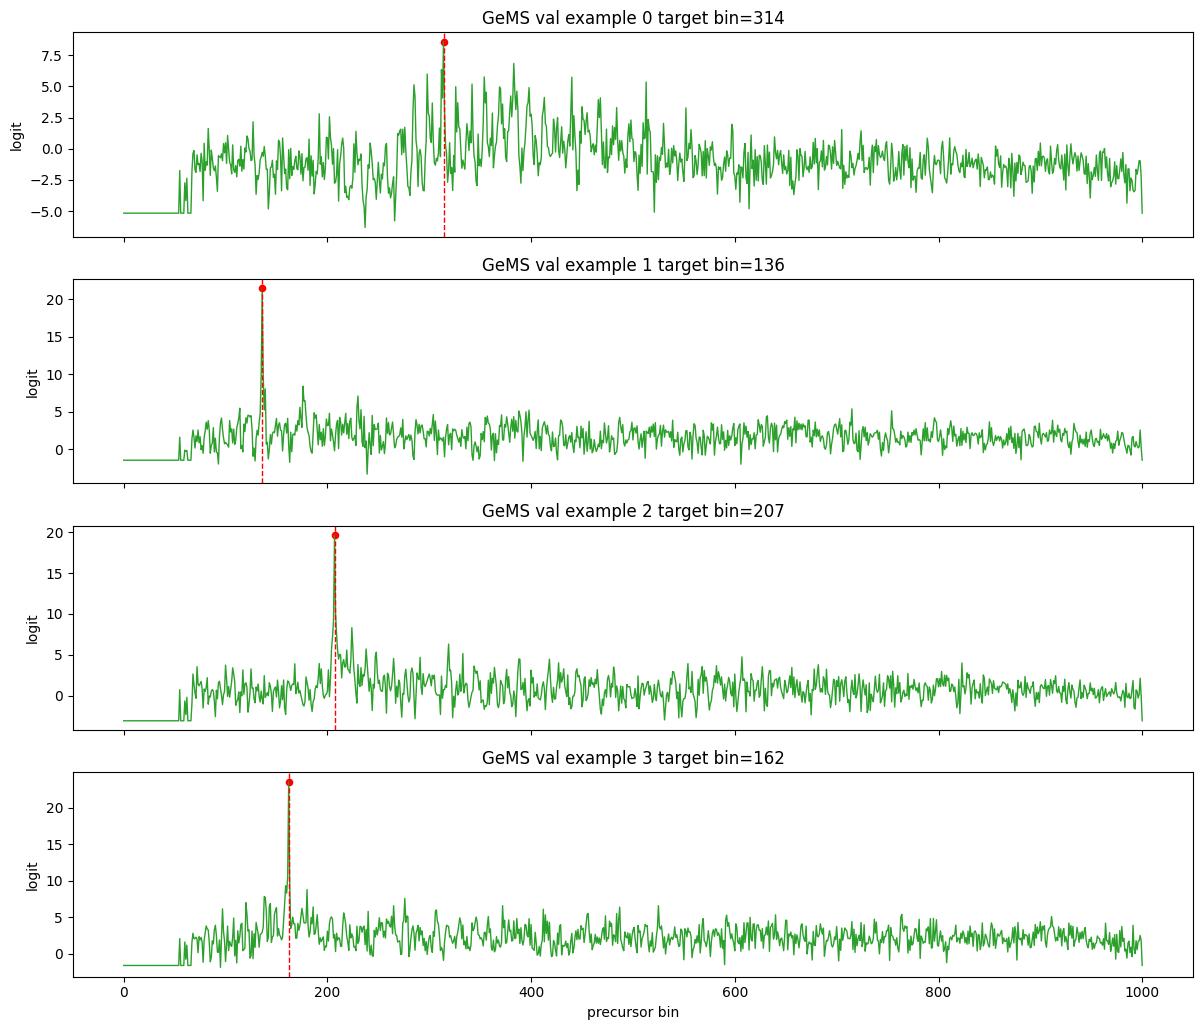

In [8]:
num_examples = min(4, logits_gems.shape[0])
fig, axes = plt.subplots(num_examples, 1, figsize=(12, 2.6 * num_examples), sharex=True)
if num_examples == 1:
    axes = [axes]
for i in range(num_examples):
    ax = axes[i]
    logits_i = logits_gems[i]
    target = int(labels_gems[i])
    ax.plot(logits_i, color="tab:green", linewidth=1)
    ax.axvline(target, color="red", linestyle="--", linewidth=1)
    ax.scatter([target], [logits_i[target]], color="red", s=20)
    ax.set_title(f"GeMS val example {i} target bin={target}")
    ax.set_ylabel("logit")
axes[-1].set_xlabel("precursor bin")
plt.tight_layout()
plt.show()